In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

print("Upload the Sunway raw_dataset.csv file:")
uploaded = files.upload()

# Get the filename (should be raw_dataset.csv or similar)
filename = list(uploaded.keys())[0]
print(f"\nLoaded: {filename}")

Upload the Sunway raw_dataset.csv file:


Saving raw_dataset.csv to raw_dataset.csv

Loaded: raw_dataset.csv


In [ ]:
df = pd.read_csv(filename)

print("=" * 60)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("=" * 60)

print("\nAll column names:")
for i, col in enumerate(df.columns):
    print(f"  [{i:2d}] {col}")

print("\n\nFirst 3 rows:")
print(df.head(3).to_string())

print("\n\nData types:")
print(df.dtypes)

Shape: 30925 rows × 51 columns

All column names:
  [ 0] Timestamp
  [ 1] Longitude
  [ 2] Latitude
  [ 3] Speed
  [ 4] Operatorname
  [ 5] Node
  [ 6] CellID
  [ 7] LAC
  [ 8] NetworkTech
  [ 9] Level
  [10] Qual
  [11] SNR
  [12] CQI
  [13] LTERSSI
  [14] ARFCN
  [15] DL_bitrate
  [16] UL_bitrate
  [17] PSC
  [18] Altitude
  [19] Accuracy
  [20] State
  [21] SERVINGTIME
  [22] BANDWIDTH
  [23] SecondCell_NODE
  [24] SecondCell_CELLID
  [25] SecondCell_RSRP
  [26] SecondCell_SNR
  [27] SecondCell_PSC
  [28] SecondCell_ARFCN
  [29] NTech1
  [30] NCellid1
  [31] NLAC1
  [32] NCell1
  [33] NARFCN1
  [34] NRxLev1
  [35] NQual1
  [36] PINGAVG
  [37] PINGMIN
  [38] PINGMAX
  [39] PINGSTDEV
  [40] PINGLOSS
  [41] TESTDOWNLINK
  [42] TESTUPLINK
  [43] TESTDOWNLINKMAX
  [44] TESTUPLINKMAX
  [45] Test_Status
  [46] Mobility
  [47] Node_Longitude
  [48] Node_Latitude
  [49] SessionID
  [50] ElapsedTime


First 3 rows:
             Timestamp   Longitude  Latitude  Speed Operatorname      Node  Ce

In [ ]:
# --- CONFIGURE THESE COLUMN NAMES ---
COL_RSRP         = 'Level'
COL_LAT          = 'Latitude'
COL_LON          = 'Longitude'
COL_NODE_LAT     = 'Node_Latitude'
COL_NODE_LON     = 'Node_Longitude'
COL_NODE_ID      = 'Node'            # Float column, values like 702072.0
COL_TECH         = 'NetworkTech'     # Values: '5G', '4G'
# --- END CONFIGURATION ---
for col_name, col_val in [('RSRP', COL_RSRP), ('Latitude', COL_LAT),
                           ('Longitude', COL_LON), ('Node_Latitude', COL_NODE_LAT),
                           ('Node_Longitude', COL_NODE_LON)]:
    if col_val in df.columns:
        print(f"  ✓ Found '{col_val}' for {col_name}")
    else:
        # Try case-insensitive search
        matches = [c for c in df.columns if col_val.lower() in c.lower()]
        if matches:
            print(f"  ⚠ '{col_val}' not found, but similar: {matches}")
        else:
            print(f"  ✗ '{col_val}' NOT FOUND — check Cell 2 output and update")


if COL_NODE_ID in df.columns:
    print(f"\nUnique Node IDs (showing first 20):")
    print(df[COL_NODE_ID].unique()[:20])
else:
    print(f"\n⚠ '{COL_NODE_ID}' column not found.")
    print("Trying to find node/cell ID columns...")
    id_candidates = [c for c in df.columns if any(x in c.lower() for x in
                     ['node', 'cell', 'cid', 'pci', 'enb', 'gnb'])]
    print(f"  Candidates: {id_candidates}")
    if id_candidates:
        for c in id_candidates:
            print(f"  Unique values in '{c}': {df[c].nunique()} values")
            print(f"  Sample: {df[c].unique()[:10]}")

# Show technology types
if COL_TECH in df.columns:
    print(f"\nTechnology distribution:")
    print(df[COL_TECH].value_counts())
else:
    tech_candidates = [c for c in df.columns if any(x in c.lower() for x in
                       ['tech', 'rat', 'network', 'type'])]
    print(f"\nTechnology column candidates: {tech_candidates}")

  ✓ Found 'Level' for RSRP
  ✓ Found 'Latitude' for Latitude
  ✓ Found 'Longitude' for Longitude
  ✓ Found 'Node_Latitude' for Node_Latitude
  ✓ Found 'Node_Longitude' for Node_Longitude

Unique Node IDs (showing first 20):
[702072. 701688. 701905. 812198. 810854. 701684. 701806.  12252. 701911.
  54681.  87496.  10171.  12243. 211399. 702063. 701997. 702023. 816443.
 702175. 810857.]

Technology distribution:
NetworkTech
5G    21032
4G     9893
Name: count, dtype: int64


In [ ]:

print("All unique nodes in dataset:")
print(sorted(df['Node'].dropna().unique()))
print(f"\nTotal unique nodes: {df['Node'].nunique()}")

# Check how many records per node
print("\nRecords per node (top 20):")
print(df['Node'].value_counts().head(20))

# Specifically check for 701905
mask = df['Node'] == 701905.0
print(f"\nRecords for Node 701905: {mask.sum()}")

# If 701905 doesn't exist, check nearby values
if mask.sum() == 0:
    close = df['Node'].dropna().unique()
    close = sorted([n for n in close if 701000 < n < 702000])
    print(f"Nodes in 701xxx range: {close}")

All unique nodes in dataset:
[np.float64(10171.0), np.float64(10191.0), np.float64(10201.0), np.float64(11161.0), np.float64(11771.0), np.float64(12232.0), np.float64(12243.0), np.float64(12252.0), np.float64(15691.0), np.float64(16151.0), np.float64(16161.0), np.float64(16372.0), np.float64(22133.0), np.float64(26740.0), np.float64(28131.0), np.float64(35372.0), np.float64(36933.0), np.float64(45721.0), np.float64(54681.0), np.float64(55382.0), np.float64(64502.0), np.float64(86456.0), np.float64(87496.0), np.float64(95182.0), np.float64(95192.0), np.float64(210038.0), np.float64(210046.0), np.float64(210077.0), np.float64(210082.0), np.float64(210083.0), np.float64(210089.0), np.float64(210135.0), np.float64(210297.0), np.float64(211399.0), np.float64(211467.0), np.float64(211635.0), np.float64(212644.0), np.float64(212660.0), np.float64(212677.0), np.float64(212680.0), np.float64(215945.0), np.float64(216175.0), np.float64(216183.0), np.float64(216209.0), np.float64(216210.0), np.fl

In [ ]:
TARGET_NODE = 701905

# Filter for target node
if COL_NODE_ID in df.columns:
    # Try both int and string matching
    node_df = df[df[COL_NODE_ID].astype(str).str.contains(str(TARGET_NODE))]
    print(f"Records matching Node {TARGET_NODE}: {len(node_df)}")
else:
    print(" Cannot filter by node. Using all data. Update COL_NODE_ID in Cell 3.")
    node_df = df.copy()


if COL_TECH in df.columns:
    tech_values = node_df[COL_TECH].unique()
    print(f"Technologies for this node: {tech_values}")


# Compute distance from UE to node using Haversine formula
def haversine_m(lat1, lon1, lat2, lon2):
    """Distance in meters between two lat/lon points."""
    R = 6371000  # Earth radius in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

node_df = node_df.copy()
node_df['distance_m'] = haversine_m(
    node_df[COL_LAT].values, node_df[COL_LON].values,
    node_df[COL_NODE_LAT].values, node_df[COL_NODE_LON].values
)
#This calculates the exact distance between the cell phone and the tower using GPS coordinates.
print(f"\nDistance statistics (meters):")
print(node_df['distance_m'].describe())
print(f"\nRSRP statistics (dBm):")
print(node_df[COL_RSRP].describe())


Records matching Node 701905: 6016
Technologies for this node: ['4G' '5G']

Distance statistics (meters):
count    6016.000000
mean      238.835240
std       158.504814
min         0.000000
25%        78.914039
50%       249.926268
75%       359.849988
max       682.631073
Name: distance_m, dtype: float64

RSRP statistics (dBm):
count    6016.000000
mean      -89.377826
std         9.878238
min      -118.500000
25%       -96.000000
50%       -90.000000
75%       -83.000000
max       -58.500000
Name: Level, dtype: float64


In [ ]:
P_TOTAL_DBM = 46.0          # Total cell EIRP (dBm) — typical macro
BW_MHZ = 100                # Bandwidth in MHz
N_PRB = 273                  # PRBs for 100 MHz (FR1, SCS=30kHz)
N_SC_PER_PRB = 12            # Subcarriers per PRB
N_RE = N_PRB * N_SC_PER_PRB  # Total REs per OFDM symbol

# Power per Resource Element
P_TX_PER_RE = P_TOTAL_DBM - 10 * np.log10(N_RE)
print(f"Assumed cell EIRP: {P_TOTAL_DBM} dBm")
print(f"Bandwidth: {BW_MHZ} MHz → {N_PRB} PRBs → {N_RE} REs")
print(f"P_TX per RE: {P_TX_PER_RE:.2f} dBm")

# Compute empirical path loss: PL = P_TX_per_RE - RSRP
node_df = node_df.copy()
node_df['path_loss_empirical'] = P_TX_PER_RE - node_df[COL_RSRP]

# Also compute 3GPP TR 38.901 UMa NLOS path loss for comparison
def path_loss_3gpp_uma_nlos(d_m, f_ghz=3.5, h_bs=25, h_ut=1.5):
    """
    3GPP TR 38.901 Table 7.4.1-1, UMa NLOS.
    d_m: distance in meters (valid for 10m to 5000m)
    f_ghz: carrier frequency in GHz
    h_bs: base station height (m)
    h_ut: UE height (m)
    """
    d_m = np.maximum(d_m, 10)  # Clamp minimum distance
    PL = (13.54 + 39.08 * np.log10(d_m)
           + 20 * np.log10(f_ghz)
           - 0.6 * (h_ut - 1.5))
    return PL

node_df['path_loss_3gpp'] = path_loss_3gpp_uma_nlos(node_df['distance_m'].values)

# Compute the offset
node_df['delta'] = node_df['path_loss_3gpp'] - node_df['path_loss_empirical']

print(f"\n{'='*60}")
print(f"PATH LOSS COMPARISON (Node {TARGET_NODE})")
print(f"{'='*60}")



Assumed cell EIRP: 46.0 dBm
Bandwidth: 100 MHz → 273 PRBs → 3276 REs
P_TX per RE: 10.85 dBm

PATH LOSS COMPARISON (Node 701905)


In [ ]:
# Create distance bins
bins = [0, 50, 150, 300, 600, 1000, 2000]
labels = ['0-50m', '50-150m', '150-300m', '300-600m', '600-1000m', '1000-2000m']
node_df['dist_bin'] = pd.cut(node_df['distance_m'], bins=bins, labels=labels)

# Aggregate statistics per bin
summary = node_df.groupby('dist_bin', observed=True).agg(
    count=('distance_m', 'count'),
    mean_dist=('distance_m', 'mean'),
    mean_rsrp=(COL_RSRP, 'mean'),
    std_rsrp=(COL_RSRP, 'std'),
    mean_pl_empirical=('path_loss_empirical', 'mean'),
    mean_pl_3gpp=('path_loss_3gpp', 'mean'),
    mean_delta=('delta', 'mean'),
    std_delta=('delta', 'std'),
).round(2)

print("\n" + "=" * 90)
print("DISTANCE-BINNED PATH LOSS COMPARISON")
print("=" * 90)
print(summary.to_string())

# Overall mean delta
valid_delta = node_df['delta'].dropna()
print(f"\n>>> Overall mean Δ (3GPP - Empirical): {valid_delta.mean():.1f} dB")
print(f">>> Overall std  Δ: {valid_delta.std():.1f} dB")



DELTA_MEAN = valid_delta.mean()



DISTANCE-BINNED PATH LOSS COMPARISON
           count  mean_dist  mean_rsrp  std_rsrp  mean_pl_empirical  mean_pl_3gpp  mean_delta  std_delta
dist_bin                                                                                                
0-50m        768      33.19     -90.99      8.91             101.83         82.94      -18.89       9.78
50-150m     1556      86.20     -91.25      9.46             102.09         99.28       -2.81      10.65
150-300m    1064     226.53     -85.43      9.96              96.28        116.13       19.85      11.14
300-600m    2594     391.39     -89.39      9.95             100.24        125.48       25.24       9.76
600-1000m     33     634.05     -89.70      4.26             100.54        133.91       33.37       4.09

>>> Overall mean Δ (3GPP - Empirical): 11.4 dB
>>> Overall std  Δ: 19.3 dB
>>> This is the number you report as your empirical correction.



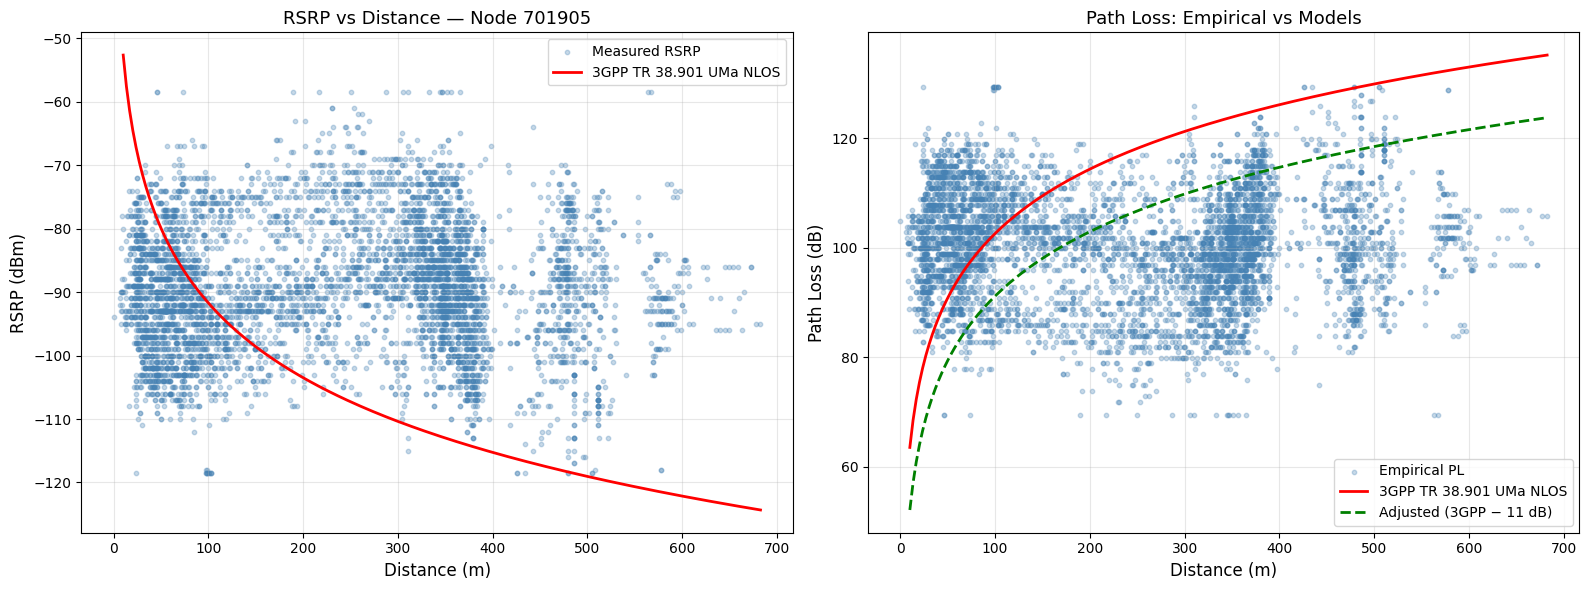

✓ Saved path_loss_comparison.png


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: RSRP vs distance
ax = axes[0]
ax.scatter(node_df['distance_m'], node_df[COL_RSRP],
           alpha=0.3, s=10, c='steelblue', label='Measured RSRP')
# Overlay 3GPP prediction (what RSRP would be if 3GPP PL were correct)
d_range = np.linspace(10, node_df['distance_m'].max(), 200)
rsrp_3gpp = P_TX_PER_RE - path_loss_3gpp_uma_nlos(d_range)
ax.plot(d_range, rsrp_3gpp, 'r-', linewidth=2, label='3GPP TR 38.901 UMa NLOS')
ax.set_xlabel('Distance (m)', fontsize=12)
ax.set_ylabel('RSRP (dBm)', fontsize=12)
ax.set_title(f'RSRP vs Distance — Node {TARGET_NODE}', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: Path loss vs distance
ax = axes[1]
ax.scatter(node_df['distance_m'], node_df['path_loss_empirical'],
           alpha=0.3, s=10, c='steelblue', label='Empirical PL')
ax.plot(d_range, path_loss_3gpp_uma_nlos(d_range),
        'r-', linewidth=2, label='3GPP TR 38.901 UMa NLOS')
# Adjusted model
ax.plot(d_range, path_loss_3gpp_uma_nlos(d_range) - DELTA_MEAN,
        'g--', linewidth=2, label=f'Adjusted (3GPP − {DELTA_MEAN:.0f} dB)')
ax.set_xlabel('Distance (m)', fontsize=12)
ax.set_ylabel('Path Loss (dB)', fontsize=12)
ax.set_title('Path Loss: Empirical vs Models', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('path_loss_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved path_loss_comparison.png")



In [ ]:

print("SENSITIVITY ANALYSIS: Effect of assumed cell EIRP")
print("=" * 60)

for p_total in [43, 44, 45, 46, 48]:
    p_per_re = p_total - 10 * np.log10(N_RE)
    pl_emp = p_per_re - node_df[COL_RSRP]
    delta = node_df['path_loss_3gpp'] - pl_emp
    print(f"  EIRP = {p_total} dBm → P/RE = {p_per_re:.1f} dBm "
          f"→ Mean Δ = {delta.mean():.1f} dB ± {delta.std():.1f}")

print("\n>>> Even at the lowest assumption (43 dBm), the Δ should still be")
print("    large enough that the conclusion holds. Report the range.\n")


SENSITIVITY ANALYSIS: Effect of assumed cell EIRP
  EIRP = 43 dBm → P/RE = 7.8 dBm → Mean Δ = 14.4 dB ± 19.3
  EIRP = 44 dBm → P/RE = 8.8 dBm → Mean Δ = 13.4 dB ± 19.3
  EIRP = 45 dBm → P/RE = 9.8 dBm → Mean Δ = 12.4 dB ± 19.3
  EIRP = 46 dBm → P/RE = 10.8 dBm → Mean Δ = 11.4 dB ± 19.3
  EIRP = 48 dBm → P/RE = 12.8 dBm → Mean Δ = 9.4 dB ± 19.3

>>> Even at the lowest assumption (43 dBm), the Δ should still be
    large enough that the conclusion holds. Report the range.



MONTE CARLO SIM + NP DETECTOR

In [ ]:

# --- SIMULATION PARAMETERS  ---
F_GHZ = 3.5               # Carrier frequency
UE_TX_POWER = 23.0         # UE max transmit power (dBm) — 3GPP
SDR_ANTENNA_GAIN = 3.0     # Eavesdropper SDR antenna gain (dBi)
SDR_NOISE_FIGURE = 6.0     # SDR receiver noise figure (dB)
PRACH_BW_HZ = 1.08e6       # PRACH bandwidth (~1 MHz for Format A1)
SIGMA_SF = 7.8             # Shadow fading std dev (dB) — 3GPP UMa NLOS
P_FA = 0.001               # False alarm probability
N_TRIALS = 2000            # Monte Carlo trials

# Thermal noise at SDR
kT = -174  # dBm/Hz at 290K
NOISE_FLOOR = kT + 10 * np.log10(PRACH_BW_HZ) + SDR_NOISE_FIGURE
print(f"SDR noise floor: {NOISE_FLOOR:.1f} dBm")

# Neyman-Pearson detection threshold (from noise-only distribution)
# Under H0 (no signal): received energy is noise only
# Under H1 (signal present): received energy is signal + noise
# We use energy detection: compare total received power against threshold

# Threshold for P_fa = 0.001 with N_TRIALS noise samples
from scipy import stats

def compute_threshold(n_trials, noise_floor_dbm, pfa):
    """
    Compute Neyman-Pearson energy detection threshold.
    Noise power in linear, then convert to dBm threshold.
    """
    noise_lin = 10**(noise_floor_dbm / 10)  # mW
    # For energy detection with Gaussian noise:
    # Under H0, received power ~ Exponential(noise_lin) per sample
    # For multiple samples averaged, use chi-squared
    # Simplified: use inverse of noise CDF
    threshold_lin = noise_lin * stats.chi2.ppf(1 - pfa, df=2) / 2
    return 10 * np.log10(threshold_lin)

THRESHOLD_DBM = compute_threshold(N_TRIALS, NOISE_FLOOR, P_FA)
print(f"Detection threshold (Pfa={P_FA}): {THRESHOLD_DBM:.1f} dBm")


def simulate_detection(N_devices, d_eavesdropper, pl_model, n_trials=N_TRIALS):
    """
    Monte Carlo simulation of PRACH burst detection.

    N_devices: number of UEs simultaneously transmitting PRACH
    d_eavesdropper: distance from UE cluster to eavesdropper (meters)
    pl_model: '3gpp' or 'adjusted'

    Returns: detection probability (Pd)
    """
    detections = 0

    for _ in range(n_trials):
        # Each device transmits with shadow fading
        total_rx_power_lin = 0.0  # in milliwatts

        for _ in range(N_devices):
            # Path loss for this device
            if pl_model == '3gpp':
                pl = path_loss_3gpp_uma_nlos(d_eavesdropper, F_GHZ)
            elif pl_model == 'adjusted':
                pl = path_loss_3gpp_uma_nlos(d_eavesdropper, F_GHZ) - DELTA_MEAN
            else:
                raise ValueError(f"Unknown model: {pl_model}")

            # Add shadow fading (log-normal)
            sf = np.random.normal(0, SIGMA_SF)

            # Received power at eavesdropper
            rx_dbm = UE_TX_POWER - pl + SDR_ANTENNA_GAIN + sf
            rx_lin = 10**(rx_dbm / 10)  # convert to milliwatts
            total_rx_power_lin += rx_lin

        # Add noise
        noise_lin = 10**(NOISE_FLOOR / 10)
        total_with_noise = total_rx_power_lin + noise_lin
        total_dbm = 10 * np.log10(total_with_noise)

        # Detection decision
        if total_dbm > THRESHOLD_DBM:
            detections += 1

    return detections / n_trials


SDR noise floor: -107.7 dBm
Detection threshold (Pfa=0.001): -99.3 dBm


In [ ]:

distances = [50, 200, 500, 1000]
N_values = [1, 2, 5, 10, 20, 50, 100, 500, 1000]
models = ['3gpp', 'adjusted']

results = {}

total_runs = len(distances) * len(N_values) * len(models)
run_count = 0

print(f"Running {total_runs} simulation configurations ({N_TRIALS} trials each)...")
print(f"This will take a few minutes.\n")

for model in models:
    for d in distances:
        for N in N_values:
            run_count += 1
            Pd = simulate_detection(N, d, model)
            results[(model, d, N)] = Pd
            if run_count % 10 == 0 or run_count == total_runs:
                print(f"  [{run_count}/{total_runs}] model={model}, "
                      f"d={d}m, N={N} → Pd = {Pd:.3f}")

print("\n✓ Simulation complete!")


Running 72 simulation configurations (2000 trials each)...
This will take a few minutes.

  [10/72] model=3gpp, d=200m, N=1 → Pd = 0.929
  [20/72] model=3gpp, d=500m, N=2 → Pd = 0.580
  [30/72] model=3gpp, d=1000m, N=5 → Pd = 0.166
  [40/72] model=adjusted, d=50m, N=10 → Pd = 1.000
  [50/72] model=adjusted, d=200m, N=20 → Pd = 1.000
  [60/72] model=adjusted, d=500m, N=50 → Pd = 1.000
  [70/72] model=adjusted, d=1000m, N=100 → Pd = 1.000
  [72/72] model=adjusted, d=1000m, N=1000 → Pd = 1.000

✓ Simulation complete!


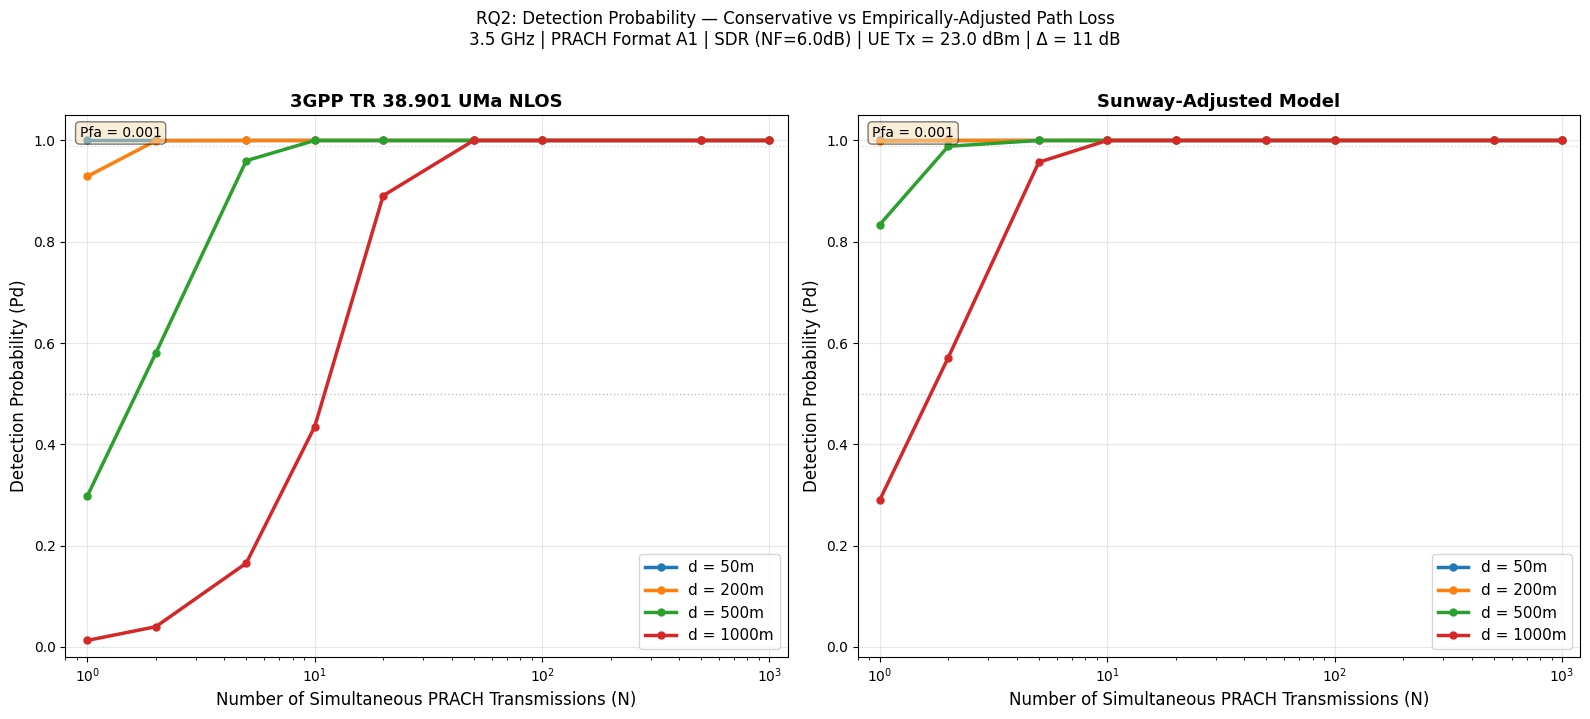

✓ Saved detection_comparison.png — USE THIS IN YOUR SLIDE


In [ ]:

# Color scheme for distances
colors = {50: '#1f77b4', 200: '#ff7f0e', 500: '#2ca02c', 1000: '#d62728'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax_idx, (ax, channel_label) in enumerate(zip(axes, ['3GPP TR 38.901 UMa NLOS', 'Sunway-Adjusted Model'])):
    model = models[ax_idx]

    for d in distances:
        Pd_vals = [results[(model, d, N)] for N in N_values]
        ax.semilogx(N_values, Pd_vals,
                     color=colors[d], linewidth=2.5,
                     marker='o', markersize=5,
                     label=f'd = {d}m')

    ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1)
    ax.axhline(y=0.99, color='gray', linestyle=':', alpha=0.3, linewidth=1)
    ax.set_xlabel('Number of Simultaneous PRACH Transmissions (N)', fontsize=12)
    ax.set_ylabel('Detection Probability (Pd)', fontsize=12)
    ax.set_title(channel_label, fontsize=13, fontweight='bold')
    ax.set_ylim([-0.02, 1.05])
    ax.set_xlim([0.8, 1200])
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.98, f'Pfa = {P_FA}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

plt.suptitle(
    'RQ2: Detection Probability — Conservative vs Empirically-Adjusted Path Loss\n'
    f'3.5 GHz | PRACH Format A1 | SDR (NF={SDR_NOISE_FIGURE}dB) | '
    f'UE Tx = {UE_TX_POWER} dBm | Δ = {DELTA_MEAN:.0f} dB',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('detection_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

for d in distances:
    # 3GPP: solid lines
    Pd_3gpp = [results[('3gpp', d, N)] for N in N_values]
    ax.semilogx(N_values, Pd_3gpp,
                 color=colors[d], linewidth=2.5,
                 marker='o', markersize=5, linestyle='-',
                 label=f'd={d}m (3GPP)')

    # Adjusted: dashed lines
    Pd_adj = [results[('adjusted', d, N)] for N in N_values]
    ax.semilogx(N_values, Pd_adj,
                 color=colors[d], linewidth=2.5,
                 marker='s', markersize=5, linestyle='--',
                 label=f'd={d}m (Adjusted)')

ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=0.99, color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('Number of Simultaneous PRACH Transmissions (N)', fontsize=13)
ax.set_ylabel('Detection Probability (Pd)', fontsize=13)
ax.set_title(
    'Detection Probability: 3GPP Model (solid) vs '
    f'Sunway-Adjusted (dashed, Δ={DELTA_MEAN:.0f}dB)\n'
    f'Pfa = {P_FA} | 3.5 GHz | UE Tx = {UE_TX_POWER} dBm | '
    f'SDR NF = {SDR_NOISE_FIGURE} dB',
    fontsize=12
)
ax.set_ylim([-0.02, 1.05])
ax.set_xlim([0.8, 1200])
ax.legend(fontsize=9, loc='lower right', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('detection_overlay.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved detection_overlay.png — ALTERNATIVE SLIDE FIGURE")


In [ ]:

print("\n" + "=" * 70)
print("KEY NUMBERS FOR YOUR SLIDE")
print("=" * 70)

print(f"\n1. Empirical correction Δ = {DELTA_MEAN:.1f} dB")
print(f"   (3GPP overestimates path loss by this much)")

print(f"\n2. Assumed cell EIRP: {P_TOTAL_DBM} dBm")
print(f"   P_TX per RE: {P_TX_PER_RE:.1f} dBm")

print(f"\n3. Detection probability highlights:")
for d in [500, 1000]:
    for N in [1, 5, 10]:
        pd_3gpp = results.get(('3gpp', d, N), 'N/A')
        pd_adj = results.get(('adjusted', d, N), 'N/A')
        if pd_3gpp != 'N/A':
            print(f"   d={d}m, N={N:3d}: "
                  f"3GPP Pd={pd_3gpp:.3f}  |  "
                  f"Adjusted Pd={pd_adj:.3f}")

print(f"\n4. Uplink link budget at 500m:")
pl_3gpp_500 = path_loss_3gpp_uma_nlos(500, F_GHZ)
pl_adj_500 = pl_3gpp_500 - DELTA_MEAN
rx_3gpp = UE_TX_POWER - pl_3gpp_500 + SDR_ANTENNA_GAIN
rx_adj = UE_TX_POWER - pl_adj_500 + SDR_ANTENNA_GAIN
print(f"   3GPP path loss at 500m:     {pl_3gpp_500:.1f} dB")
print(f"   Adjusted path loss at 500m: {pl_adj_500:.1f} dB")
print(f"   Rx power (3GPP):     {rx_3gpp:.1f} dBm  "
      f"{'→ ABOVE' if rx_3gpp > NOISE_FLOOR else '→ BELOW'} noise floor ({NOISE_FLOOR:.1f} dBm)")
print(f"   Rx power (Adjusted): {rx_adj:.1f} dBm  "
      f"{'→ ABOVE' if rx_adj > NOISE_FLOOR else '→ BELOW'} noise floor ({NOISE_FLOOR:.1f} dBm)")
print(f"   SNR margin (3GPP):     {rx_3gpp - NOISE_FLOOR:.1f} dB")
print(f"   SNR margin (Adjusted): {rx_adj - NOISE_FLOOR:.1f} dB")

print("\n" + "=" * 70)
print("Copy these numbers directly into your slide.")
print("Use detection_comparison.png or detection_overlay.png as the figure.")
print("=" * 70)


In [ ]:

files.download('path_loss_comparison.png')
files.download('detection_comparison.png')
files.download('detection_overlay.png')
print("✓ All files downloaded!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: detection_overlay.png